In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import operator

In [31]:
load_dotenv()

True

In [32]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [33]:
llm = ChatOpenRouter(model="openai/gpt-4o-mini")

def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {'messages': [response]}


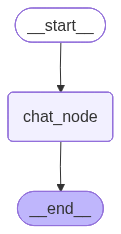

In [34]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [35]:
initial_state = {
    'messages': [HumanMessage(content="What is the capital of India.")]
}

result = workflow.invoke(initial_state)
result

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [36]:
thread_id = '1'

while True:
    user_message = input('Type Here: ')
    print(user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = workflow.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print("AI: ", response['messages'][-1].content)


Hii, I am Aryan !
AI:  Hi Aryan! How can I assist you today?
I want to know my name 
AI:  Your name is Aryan! If you meant something else or need more information, feel free to clarify!
I am in Bangalore, Introduce yourself to me 
AI:  Hello Aryan! I'm an AI created to assist you with a variety of topics. Whether you have questions about technology, need help with learning, want to chat about hobbies, or anything else, I'm here for you. Since you're in Bangalore, I can also provide information about the city, local culture, and more if you’re interested. How can I help you today?
I need your interanal details 
AI:  I'm sorry, but I can't provide internal details or specific information about how I function. However, I can tell you that I'm designed to assist with answering questions, providing information, and aiding in conversation across a broad range of topics. If you have any specific questions or topics you’d like to explore, feel free to ask!
I want to know your name, specificati

In [ ]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hii, I am Aryan !', additional_kwargs={}, response_metadata={}, id='7da802ce-4ec7-4f72-819d-9c77d1ee944a'), AIMessage(content='Hi Aryan! How can I assist you today?', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-4o-mini', 'id': 'gen-1780664055-7V9VbAFIljE4Hr1rQYOJ', 'created': 1780664055, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'system_fingerprint': 'fp_83ca678e0e'}, id='lc_run--019e97d9-3887-78f2-947d-1575a49a5d7d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}, 'output_token_details': {'reasoning': 0}}), HumanMessage(content='I want to know my name ', additional_kwargs={}, response_metadata={}, id='dfa6e561-1abf-4731-95a5-1b94a0099cce'), AIMessage(content='Your name is Aryan! If you meant something else or need m

: 